# Face Recognition Models Evaluation
## Creating Visualizations

## loading data

In [221]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [222]:
# Ensure the file path is compatible with Windows
classification = "eval_classification.csv"
verification = "eval_verification.csv"
verification_aug = "eval_verification_augmented.csv"

# load_csv function to load CSV files
def load_csv(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file {file_path} does not exist.")
    
    return pd.read_csv(file_path)

# Load the datasets into independent variables
classification_data = load_csv(classification)
verification_data = load_csv(verification)
verification_aug_data = load_csv(verification_aug)

## Classification

### Preview



In [223]:
print("Classification Data:")
print(classification_data.head())

Classification Data:
       model_name  accuracy  precision    recall  f1_score
0    PCA Original  0.211480   0.180962  0.211480  0.113033
1   PCA Augmented  0.443353   0.484201  0.443353  0.421646
2    LPB Original  0.305136   0.273225  0.305136  0.248397
3   LPB Augmented  0.356495   0.306006  0.356495  0.314002
4  VGG16 Original  0.438066   0.406397  0.438066  0.388875


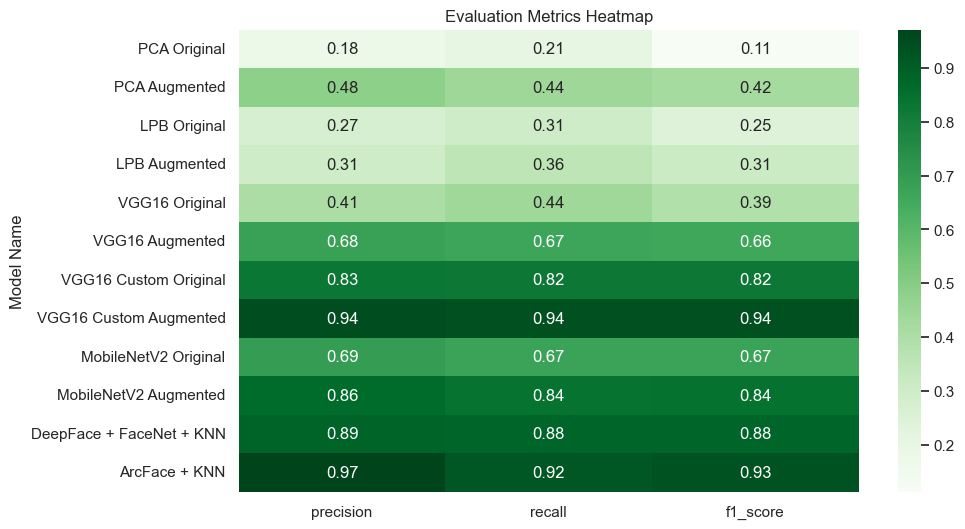

In [224]:
# Plot heatmap for evaluation metrics
plt.figure(figsize=(10, 6))
sns.heatmap(classification_data.set_index('model_name').iloc[:, 1:], annot=True, cmap='Greens', fmt='.2f')
plt.title('Evaluation Metrics Heatmap')
plt.ylabel('Model Name')
plt.show()

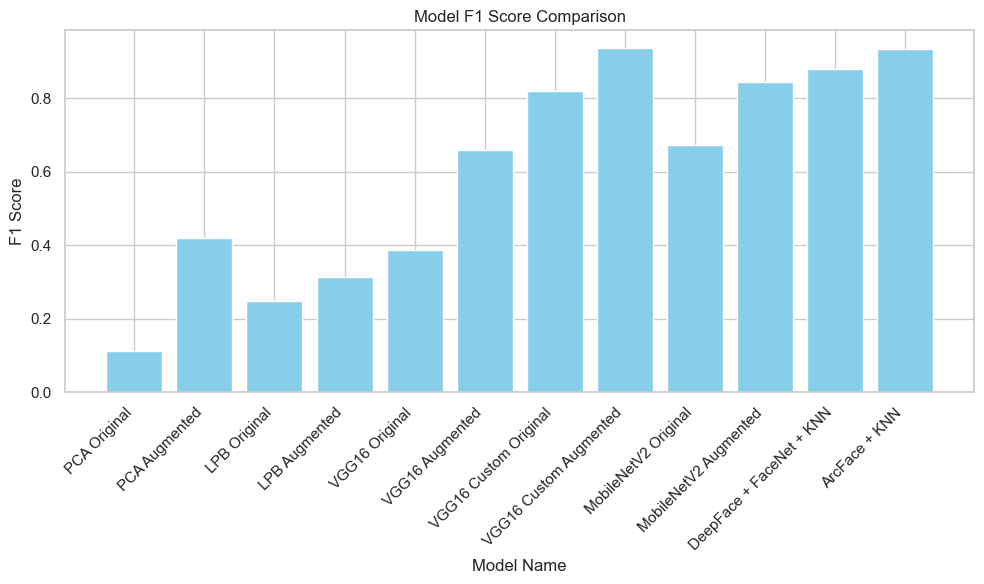

In [225]:
# Plot bar chart for accuracy
plt.figure(figsize=(10, 6))
plt.bar(classification_data['model_name'], classification_data['f1_score'], color='skyblue')
plt.xlabel('Model Name')
plt.ylabel('F1 Score')
plt.title('Model F1 Score Comparison')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

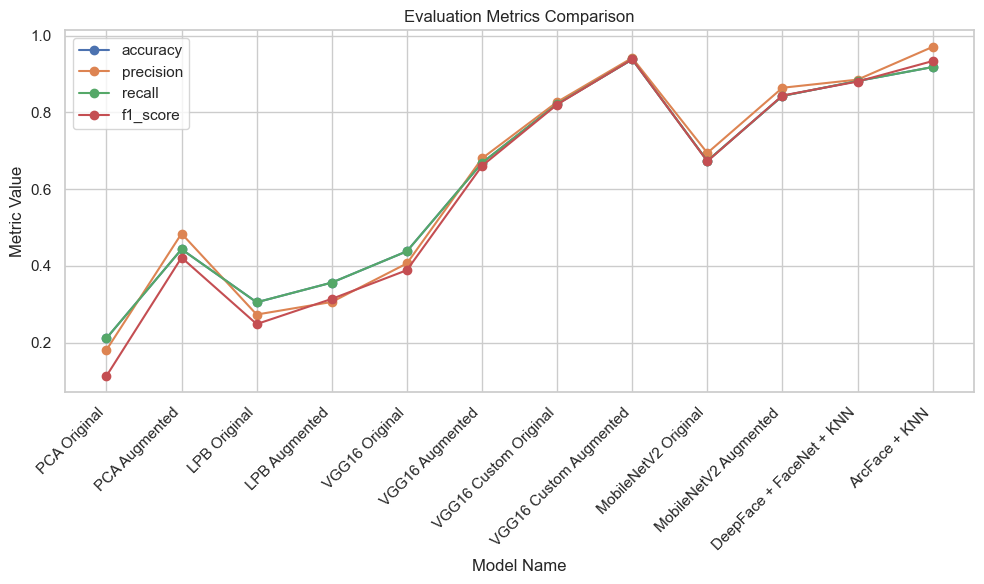

In [226]:
# Plot line chart for metrics comparison
plt.figure(figsize=(10, 6))
for metric in ['accuracy', 'precision', 'recall', 'f1_score']:
    plt.plot(classification_data['model_name'], classification_data[metric], marker='o', label=metric)

plt.xlabel('Model Name')
plt.ylabel('Metric Value')
plt.title('Evaluation Metrics Comparison')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## Verification

In [227]:
print("\nVerification Data:")
print(verification_data.head())
print("\nVerification Augmented Data:")
print(verification_aug_data.head())


Verification Data:
               model_name       EER       AUC  pairs_tested
0          VGG16 Original  0.335347  0.728088           662
1         VGG16 Augmented  0.380665  0.665524           662
2   VGG16 Custom Original  0.226586  0.736352           662
3  VGG16 Custom Augmented  0.223565  0.602929           662
4    MobileNetV2 Original  0.416918  0.599702           662

Verification Augmented Data:
                     model_name       EER       AUC  pairs_tested
0          VGG16 Original (Aug)  0.355740  0.700878          2648
1         VGG16 Augmented (Aug)  0.293807  0.757156          2648
2   VGG16 Custom Original (Aug)  0.335347  0.683246          2648
3  VGG16 Custom Augmented (Aug)  0.070242  0.832562          2648
4    MobileNetV2 Original (Aug)  0.453172  0.570853          2648


## Original VS Augmented Data

### Classification

In [228]:
ori_aug = classification_data.iloc[:-2].copy()
print(ori_aug)

               model_name  accuracy  precision    recall  f1_score
0            PCA Original  0.211480   0.180962  0.211480  0.113033
1           PCA Augmented  0.443353   0.484201  0.443353  0.421646
2            LPB Original  0.305136   0.273225  0.305136  0.248397
3           LPB Augmented  0.356495   0.306006  0.356495  0.314002
4          VGG16 Original  0.438066   0.406397  0.438066  0.388875
5         VGG16 Augmented  0.668429   0.680145  0.668429  0.660622
6   VGG16 Custom Original  0.821752   0.827174  0.821752  0.820499
7  VGG16 Custom Augmented  0.938066   0.942100  0.938066  0.938454
8    MobileNetV2 Original  0.673716   0.694302  0.673716  0.672600
9   MobileNetV2 Augmented  0.842900   0.864215  0.842900  0.843958


In [229]:
# Extract 'Original' or 'Augmented' from model_name
ori_aug['type'] = ori_aug['model_name'].apply(lambda x: 'Original' if 'Original' in x else 'Augmented')

# Extract base model name
ori_aug['base_model'] = ori_aug['model_name'].str.replace(' Original', '', regex=False)
ori_aug['base_model'] = ori_aug['base_model'].str.replace(' Augmented', '', regex=False)

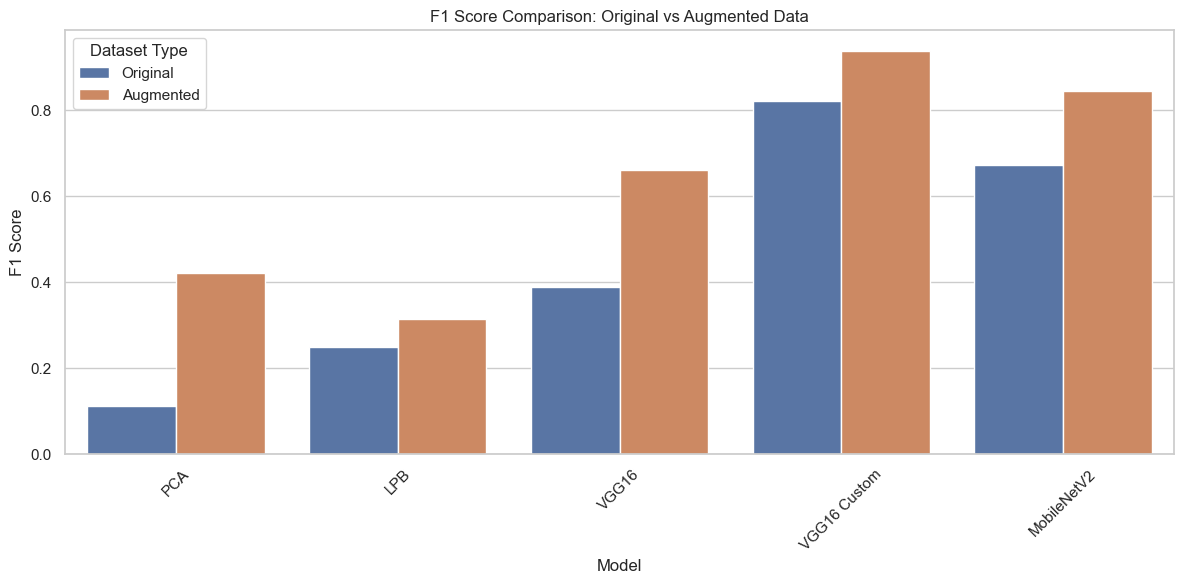

In [230]:
plt.figure(figsize=(12, 6))
sns.barplot(data=ori_aug, x='base_model', y='f1_score', hue='type')
plt.title('F1 Score Comparison: Original vs Augmented Data')
plt.ylabel('F1 Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.legend(title='Dataset Type')
plt.tight_layout()
plt.show()


<Figure size 1400x700 with 0 Axes>

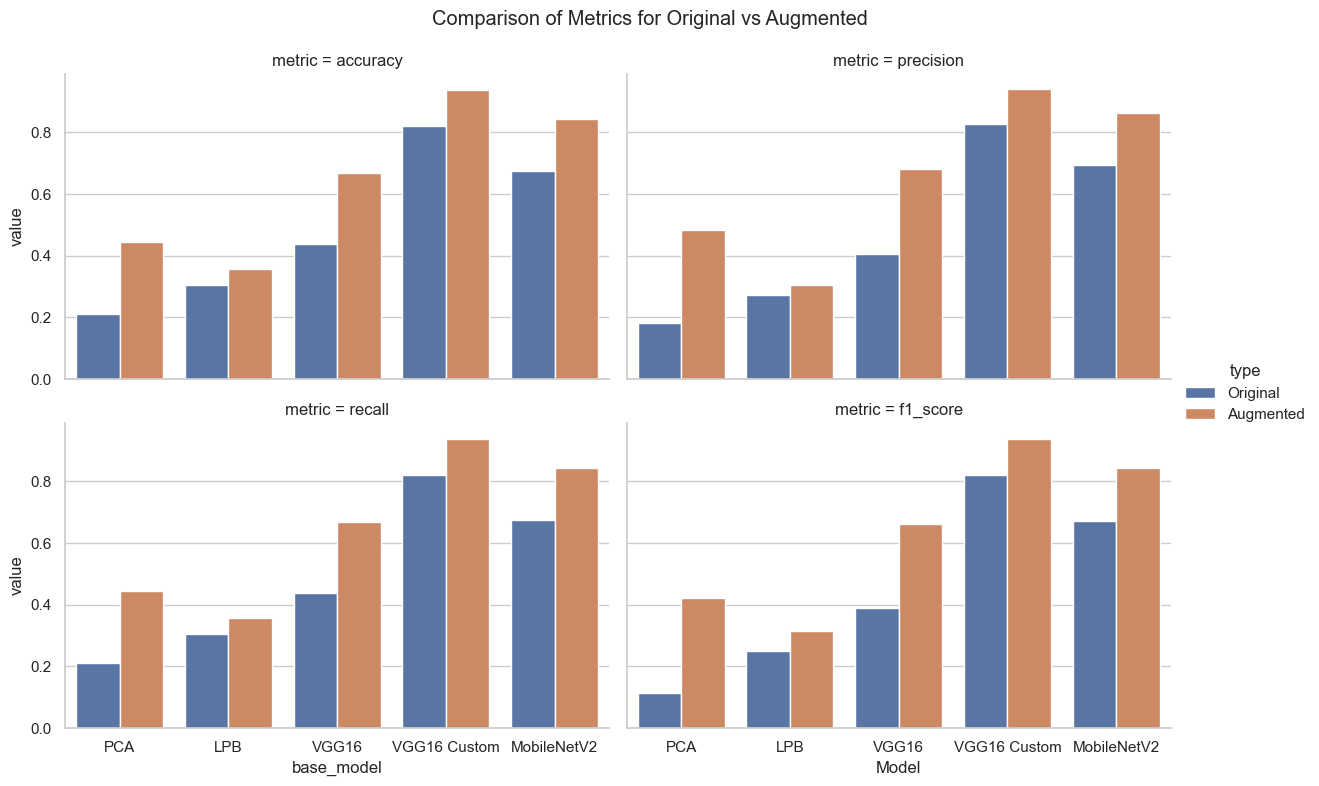

In [231]:
import pandas as pd

# Pivot to get better shape for grouped bar plot
pivot_df = ori_aug.melt(id_vars=['base_model', 'type'], 
                        value_vars=['accuracy', 'precision', 'recall', 'f1_score'],
                        var_name='metric', value_name='value')

plt.figure(figsize=(14, 7))
sns.catplot(data=pivot_df, x='base_model', y='value', hue='type', col='metric', kind='bar',
            col_wrap=2, height=4, aspect=1.5)
plt.subplots_adjust(top=0.9)
plt.xlabel('Model')
plt.suptitle('Comparison of Metrics for Original vs Augmented')
plt.show()


In [232]:
# Pivot with MultiIndex columns
pivot = ori_aug.pivot(index='base_model', columns='type', values=['accuracy', 'precision', 'recall', 'f1_score'])

# Access the metric values correctly from the MultiIndex columns
# Structure is like: pivot[<metric>][<type>]
diff = pivot.xs('Augmented', axis=1, level=1) - pivot.xs('Original', axis=1, level=1)

# Compute the average difference
avg_diff = diff.mean()

print("Average metric differences (Augmented - Original):")
print(avg_diff)


Average metric differences (Augmented - Original):
accuracy     0.159819
precision    0.178922
recall       0.159819
f1_score     0.187056
dtype: float64


In [233]:
# Store the F1 score in a variable
f1_score_diff = avg_diff['f1_score']

print("F1 Score difference:", f1_score_diff)


F1 Score difference: 0.18705561730697143


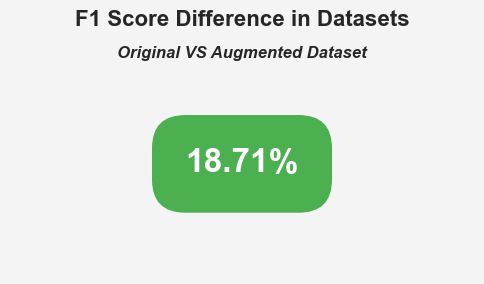

In [234]:
# Assign the value of f1_score_diff to "value"
value = f1_score_diff

# Convert value to percentage
value_percentage = value * 100
value_text = f"{value_percentage:.2f}%"

# Create figure
fig, ax = plt.subplots(figsize=(5, 3))
fig.patch.set_facecolor('#f4f4f4')
ax.axis('off')  # turn off axes

# Draw the "card"
bbox_props = dict(boxstyle="round,pad=1", facecolor="#4CAF50", edgecolor="none")
ax.text(0.5, 0.5, f"{value_text}", 
        color='white', fontsize=24, fontweight='bold',
        ha='center', va='center', bbox=bbox_props)
ax.set_title("F1 Score Difference in Datasets", fontsize=16, fontweight='bold', pad=20)
ax.text(0.5, 1, "Original VS Augmented Dataset", fontsize=12, fontweight='bold',  style='italic' ,ha='center', va='center')


# Show the card

plt.tight_layout()
plt.show()


### Verification

#### Original

In [235]:
# Copy data
ori_aug2 = verification_data.iloc[:-1].copy()
print(ori_aug2)

# Extract type
ori_aug2['type'] = ori_aug2['model_name'].apply(
    lambda x: 'Original' if 'Original' in x else ('Augmented' if 'Augmented' in x else 'Other'))

# Extract base model name
ori_aug2['base_model'] = ori_aug2['model_name'].str.replace(' Original', '', regex=False)
ori_aug2['base_model'] = ori_aug2['base_model'].str.replace(' Augmented', '', regex=False)


               model_name       EER       AUC  pairs_tested
0          VGG16 Original  0.335347  0.728088           662
1         VGG16 Augmented  0.380665  0.665524           662
2   VGG16 Custom Original  0.226586  0.736352           662
3  VGG16 Custom Augmented  0.223565  0.602929           662
4    MobileNetV2 Original  0.416918  0.599702           662
5   MobileNetV2 Augmented  0.486405  0.542584           662
6          DeepFace + KNN  0.410876  0.631183           662


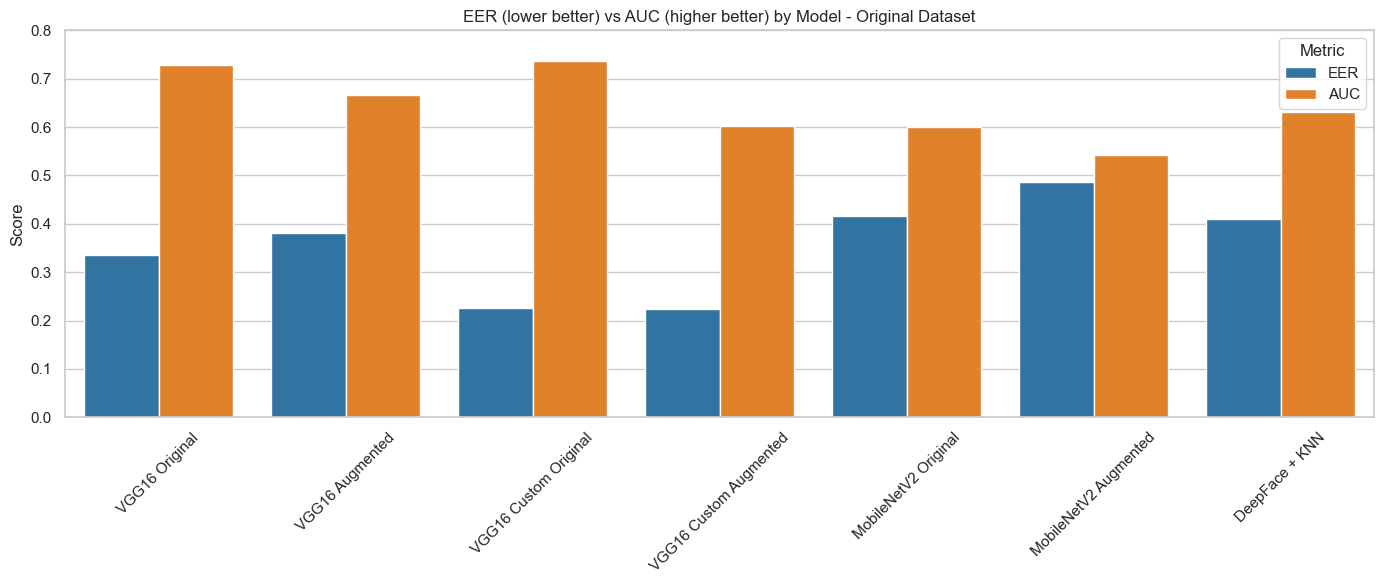

In [253]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the dataframe to long format
melted_metrics = ori_aug2.melt(
    id_vars=['model_name'],
    value_vars=['EER', 'AUC'],
    var_name='metric',
    value_name='value'
)

# Plot side-by-side bars per model
plt.figure(figsize=(14, 6))
sns.barplot(data=melted_metrics, x='model_name', y='value', hue='metric', palette=['#1f77b4', '#ff7f0e'])
plt.title("EER (lower better) vs AUC (higher better) by Model - Original Dataset")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 0.8)
plt.xticks(rotation=45)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


In [237]:
# Step 1: Remove unpaired model
ori_aug2_filtered = ori_aug2[ori_aug2['type'] != 'Other'].copy()
print(ori_aug2_filtered)

# Step 2: Pivot to compare Original vs Augmented
pivot = ori_aug2_filtered.pivot(index='base_model', columns='type', values=['EER', 'AUC'])

# Step 3: Calculate the difference (Augmented - Original)
eer_diff = pivot['EER']['Augmented'] - pivot['EER']['Original']
auc_diff = pivot['AUC']['Augmented'] - pivot['AUC']['Original']

# Step 4: Compute average differences
avg_eer_diff = eer_diff.mean()
avg_auc_diff = auc_diff.mean()

# Output the results
print("Average EER change (Augmented - Original):", avg_eer_diff)
print("Average AUC change (Augmented - Original):", avg_auc_diff)


               model_name       EER       AUC  pairs_tested       type  \
0          VGG16 Original  0.335347  0.728088           662   Original   
1         VGG16 Augmented  0.380665  0.665524           662  Augmented   
2   VGG16 Custom Original  0.226586  0.736352           662   Original   
3  VGG16 Custom Augmented  0.223565  0.602929           662  Augmented   
4    MobileNetV2 Original  0.416918  0.599702           662   Original   
5   MobileNetV2 Augmented  0.486405  0.542584           662  Augmented   

     base_model  
0         VGG16  
1         VGG16  
2  VGG16 Custom  
3  VGG16 Custom  
4   MobileNetV2  
5   MobileNetV2  
Average EER change (Augmented - Original): 0.03726082578046325
Average AUC change (Augmented - Original): -0.08436852529641022


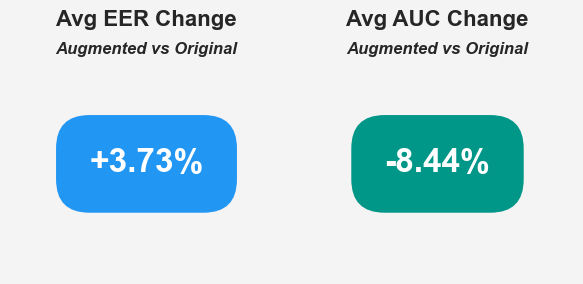

In [251]:
import matplotlib.pyplot as plt

# Sample values (replace these with your actual values)
eer_diff_avg = avg_eer_diff       # From earlier: Augmented - Original
auc_diff_avg = avg_auc_diff       # From earlier: Augmented - Original

# Convert to percentages
eer_pct = eer_diff_avg * 100
auc_pct = auc_diff_avg * 100

# Format texts
eer_text = f"{eer_pct:+.2f}%"
auc_text = f"{auc_pct:+.2f}%"

# Create side-by-side cards
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
fig.patch.set_facecolor('#f4f4f4')

# --- EER Card
axes[0].axis('off')
bbox_eer = dict(boxstyle="round,pad=1", facecolor="#2196F3", edgecolor="none")  # Red-ish
axes[0].text(0.5, 0.5, eer_text, 
             color='white', fontsize=24, fontweight='bold',
             ha='center', va='center', bbox=bbox_eer)
axes[0].set_title("Avg EER Change", fontsize=16, fontweight='bold', pad=20)
axes[0].text(0.5, 1, "Augmented vs Original", fontsize=12, fontweight='bold', style='italic', ha='center')

# --- AUC Card
axes[1].axis('off')
bbox_auc = dict(boxstyle="round,pad=1", facecolor="#009688", edgecolor="none")  # Blue
axes[1].text(0.5, 0.5, auc_text, 
             color='white', fontsize=24, fontweight='bold',
             ha='center', va='center', bbox=bbox_auc)
axes[1].set_title("Avg AUC Change", fontsize=16, fontweight='bold', pad=20)
axes[1].text(0.5, 1, "Augmented vs Original", fontsize=12, fontweight='bold', style='italic', ha='center')

# Tidy layout
plt.tight_layout()
plt.show()


#### Augmented

In [255]:
# Copy data
ori_aug3 = verification_aug_data.iloc[:-1].copy()
print(ori_aug3)

# Extract type
ori_aug3['type'] = ori_aug3['model_name'].apply(
    lambda x: 'Original' if 'Original' in x else ('Augmented' if 'Augmented' in x else 'Other'))

# Extract base model name
ori_aug3['base_model'] = ori_aug3['model_name'].str.replace(' Original', '', regex=False)
ori_aug3['base_model'] = ori_aug3['base_model'].str.replace(' Augmented', '', regex=False)


                     model_name       EER       AUC  pairs_tested
0          VGG16 Original (Aug)  0.355740  0.700878          2648
1         VGG16 Augmented (Aug)  0.293807  0.757156          2648
2   VGG16 Custom Original (Aug)  0.335347  0.683246          2648
3  VGG16 Custom Augmented (Aug)  0.070242  0.832562          2648
4    MobileNetV2 Original (Aug)  0.453172  0.570853          2648
5   MobileNetV2 Augmented (Aug)  0.434290  0.586471          2648
6          DeepFace + KNN (Aug)  0.382175  0.673890          2648


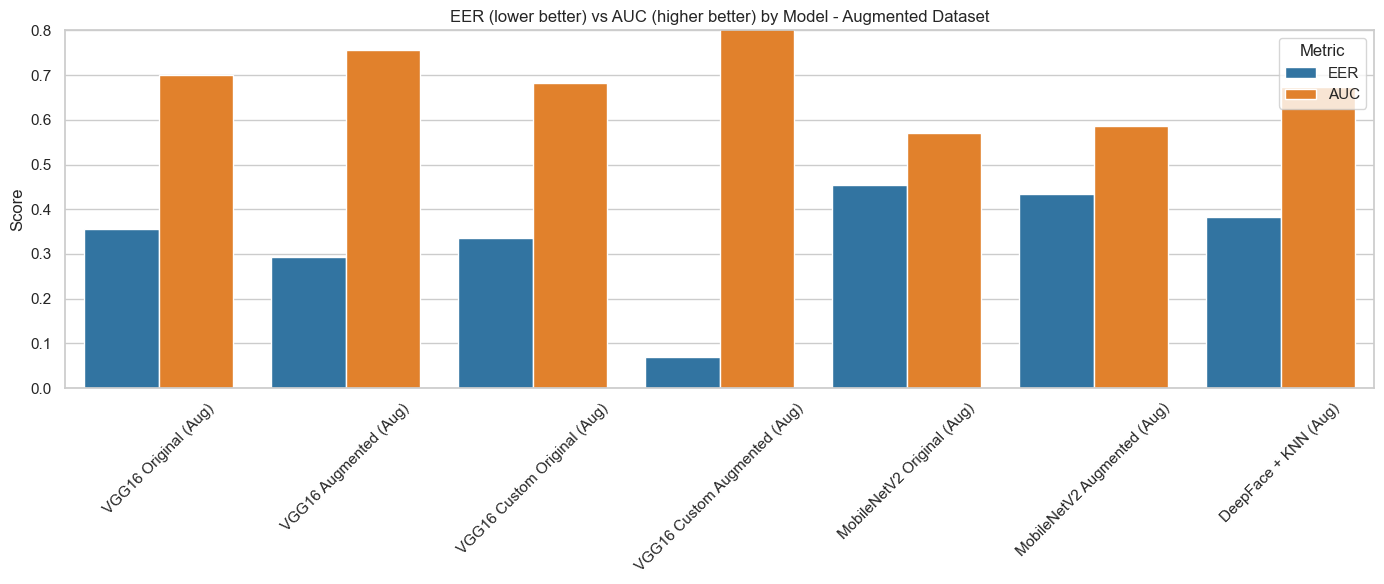

In [261]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the dataframe to long format
melted_metrics = ori_aug3.melt(
    id_vars=['model_name'],
    value_vars=['EER', 'AUC'],
    var_name='metric',
    value_name='value'
)

# Plot side-by-side bars per model
plt.figure(figsize=(14, 6))
sns.barplot(data=melted_metrics, x='model_name', y='value', hue='metric', palette=['#1f77b4', '#ff7f0e'])
plt.title("EER (lower better) vs AUC (higher better) by Model - Augmented Dataset")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 0.8)
plt.xticks(rotation=45)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


In [257]:
# Step 1: Remove unpaired model
ori_aug3_filtered = ori_aug3[ori_aug3['type'] != 'Other'].copy()
print(ori_aug3_filtered)

# Step 2: Pivot to compare Original vs Augmented
pivot = ori_aug3_filtered.pivot(index='base_model', columns='type', values=['EER', 'AUC'])

# Step 3: Calculate the difference (Augmented - Original)
eer_diff = pivot['EER']['Augmented'] - pivot['EER']['Original']
auc_diff = pivot['AUC']['Augmented'] - pivot['AUC']['Original']

# Step 4: Compute average differences
avg_eer_diff = eer_diff.mean()
avg_auc_diff = auc_diff.mean()

# Output the results
print("Average EER change (Augmented - Original):", avg_eer_diff)
print("Average AUC change (Augmented - Original):", avg_auc_diff)


                     model_name       EER       AUC  pairs_tested       type  \
0          VGG16 Original (Aug)  0.355740  0.700878          2648   Original   
1         VGG16 Augmented (Aug)  0.293807  0.757156          2648  Augmented   
2   VGG16 Custom Original (Aug)  0.335347  0.683246          2648   Original   
3  VGG16 Custom Augmented (Aug)  0.070242  0.832562          2648  Augmented   
4    MobileNetV2 Original (Aug)  0.453172  0.570853          2648   Original   
5   MobileNetV2 Augmented (Aug)  0.434290  0.586471          2648  Augmented   

           base_model  
0         VGG16 (Aug)  
1         VGG16 (Aug)  
2  VGG16 Custom (Aug)  
3  VGG16 Custom (Aug)  
4   MobileNetV2 (Aug)  
5   MobileNetV2 (Aug)  
Average EER change (Augmented - Original): -0.11530715005035241
Average AUC change (Augmented - Original): 0.07373708101727183


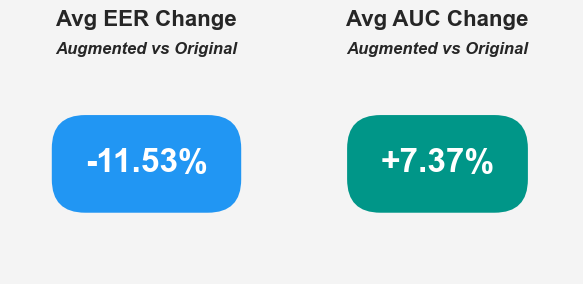

In [258]:
import matplotlib.pyplot as plt

# Sample values (replace these with your actual values)
eer_diff_avg = avg_eer_diff       # From earlier: Augmented - Original
auc_diff_avg = avg_auc_diff       # From earlier: Augmented - Original

# Convert to percentages
eer_pct = eer_diff_avg * 100
auc_pct = auc_diff_avg * 100

# Format texts
eer_text = f"{eer_pct:+.2f}%"
auc_text = f"{auc_pct:+.2f}%"

# Create side-by-side cards
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
fig.patch.set_facecolor('#f4f4f4')

# --- EER Card
axes[0].axis('off')
bbox_eer = dict(boxstyle="round,pad=1", facecolor="#2196F3", edgecolor="none")  # Red-ish
axes[0].text(0.5, 0.5, eer_text, 
             color='white', fontsize=24, fontweight='bold',
             ha='center', va='center', bbox=bbox_eer)
axes[0].set_title("Avg EER Change", fontsize=16, fontweight='bold', pad=20)
axes[0].text(0.5, 1, "Augmented vs Original", fontsize=12, fontweight='bold', style='italic', ha='center')

# --- AUC Card
axes[1].axis('off')
bbox_auc = dict(boxstyle="round,pad=1", facecolor="#009688", edgecolor="none")  # Blue
axes[1].text(0.5, 0.5, auc_text, 
             color='white', fontsize=24, fontweight='bold',
             ha='center', va='center', bbox=bbox_auc)
axes[1].set_title("Avg AUC Change", fontsize=16, fontweight='bold', pad=20)
axes[1].text(0.5, 1, "Augmented vs Original", fontsize=12, fontweight='bold', style='italic', ha='center')

# Tidy layout
plt.tight_layout()
plt.show()
